# CIFAR-10 **Animal** Image Classification with a CNN

This notebook builds a Convolutional Neural Network (CNN) that classifies images into
**6 animal categories** taken from the CIFAR-10 dataset:

> `bird`, `cat`, `deer`, `dog`, `frog`, `horse`

The original CIFAR-10 dataset has 10 classes, 4 of which are vehicles
(`airplane`, `automobile`, `ship`, `truck`). We deliberately **drop the vehicle
classes** so the model only ever has to tell animals apart from other animals.

This notebook is adapted and heavily re-commented from the general structure of
popular public CIFAR-10 CNN walkthroughs (e.g. Farzad Nekouei's
"CIFAR-10 Image Classification with CNN" on Kaggle), rewritten from scratch here so that:

1. Only the **animal** subset of CIFAR-10 is used.
2. Every cell is explained in plain language, aimed at someone who has
   never built a CNN before.
3. At the end, we discuss exactly **which hyperparameters to tune**, and how
   tuning them trades off accuracy against overfitting.

### What is CIFAR-10?
CIFAR-10 is a classic benchmark dataset of 60,000 tiny (32×32 pixel) color
photographs, split into 10 categories, 6,000 images per category
(5,000 for training, 1,000 for testing). It ships directly with Keras, so no
manual download is required — `keras.datasets.cifar10.load_data()` handles it.

### Why filter down to only animals?
- It turns a 10-class problem into an easier **6-class problem**, which is a
  nice way to see how dataset design affects model difficulty.
- Animal classes (bird, cat, deer, dog, frog, horse) are visually more similar
  to *each other* than to vehicles, so this is actually a slightly **harder**
  fine-grained task than the full 10-class problem, even though there are
  fewer classes — a good learning example of "fewer classes doesn't always
  mean easier."


## 1. Import Libraries

We import:
- `tensorflow` / `keras` — to build, train, and evaluate the CNN.
- `numpy` — for array manipulation (filtering, reshaping, etc.).
- `matplotlib` / `seaborn` — for plotting images, training curves, and the
  confusion matrix.
- `sklearn.metrics` — for a detailed classification report and confusion
  matrix once the model is trained.


In [2]:
# --- Core deep learning library ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# --- Numerical / data handling ---
import numpy as np

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Evaluation metrics ---
from sklearn.metrics import confusion_matrix, classification_report

# Make plots a reasonable default size
plt.rcParams['figure.figsize'] = (8, 5)

# Set random seeds so results are repeatable between runs.
# (Beginner note: CNNs use random numbers to initialize their weights and to
# shuffle data. Fixing the seed doesn't guarantee 100% identical results on
# GPU, due to floating point non-determinism, but it makes results *close to*
# reproducible, which is good practice when experimenting with hyperparameters.)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 2. Load the Full CIFAR-10 Dataset

`keras.datasets.cifar10.load_data()` downloads (and caches) the dataset the
first time it's called, and returns NumPy arrays:

- `train_images`: shape `(50000, 32, 32, 3)` — 50,000 RGB images, 32×32 pixels.
- `train_labels`: shape `(50000, 1)` — an integer 0–9 for each image.
- `test_images` / `test_labels`: the same, but 10,000 held-out images.

The 10 original class indices are:

| id | class      | type    |
|----|------------|---------|
| 0  | airplane   | vehicle |
| 1  | automobile | vehicle |
| 2  | bird       | animal  |
| 3  | cat        | animal  |
| 4  | deer       | animal  |
| 5  | dog        | animal  |
| 6  | frog       | animal  |
| 7  | horse      | animal  |
| 8  | ship       | vehicle |
| 9  | truck      | vehicle |

We will keep ids `2, 3, 4, 5, 6, 7` only.


In [4]:
# Download/load the full 10-class CIFAR-10 dataset.
# The first time this runs it will download ~170 MB from the internet and
# cache it locally (usually under ~/.keras/datasets), so subsequent runs are fast.
(train_images_full, train_labels_full), (test_images_full, test_labels_full) = \
    keras.datasets.cifar10.load_data()

print("Full training set:", train_images_full.shape, train_labels_full.shape)
print("Full test set:    ", test_images_full.shape, test_labels_full.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 156s 1us/step
Full training set: (50000, 32, 32, 3) (50000, 1)
Full test set:     (10000, 32, 32, 3) (10000, 1)


## 3. Keep Only the Animal Classes

CIFAR-10's label array just stores an integer id per image (0–9). To restrict
the dataset to animals we:

1. Define which original ids count as "animal" (`2,3,4,5,6,7`).
2. Build a boolean **mask** that is `True` wherever an image's label is one of
   those ids.
3. Use that mask to select only the matching images/labels (`numpy` boolean
   indexing — a very common and efficient pattern).
4. **Remap** the surviving labels from their original ids (2–7) down to a
   fresh `0–5` range. This matters because our output layer will have exactly
   6 neurons (one per animal class), and Keras expects class labels used for
   one-hot encoding / `sparse_categorical_crossentropy` to start at 0 and run
   contiguously up to `num_classes - 1`. If we fed in raw labels like
   `2, 3, 4, 5, 6, 7` directly, Keras would assume there are 8 classes
   (0 through 7) and allocate two output neurons (for ids 0 and 1) that could
   never be the correct answer — wasted capacity and a confusing setup for
   anyone reading the code later.


In [5]:
# Original CIFAR-10 class names, indexed by their original 0-9 id.
CIFAR10_CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# The original ids we want to KEEP (animals only).
ANIMAL_CLASS_IDS = [2, 3, 4, 5, 6, 7]   # bird, cat, deer, dog, frog, horse

# Human-readable names for our new, smaller 6-class problem, in the SAME
# order as ANIMAL_CLASS_IDS so that new label `i` corresponds to ANIMAL_NAMES[i].
ANIMAL_NAMES = [CIFAR10_CLASS_NAMES[i] for i in ANIMAL_CLASS_IDS]
NUM_CLASSES = len(ANIMAL_NAMES)

# A lookup dict that maps an OLD label (2,3,4,5,6,7) to a NEW, contiguous
# label (0,1,2,3,4,5). E.g. {2: 0, 3: 1, 4: 2, 5: 3, 6: 4, 7: 5}
OLD_TO_NEW_LABEL = {old_id: new_id for new_id, old_id in enumerate(ANIMAL_CLASS_IDS)}

print("Animal classes kept:", ANIMAL_NAMES)
print("Old id -> New id mapping:", OLD_TO_NEW_LABEL)


def filter_to_animals(images, labels):
    '''Keep only the rows whose label is an animal class, and remap labels
    to a contiguous 0..NUM_CLASSES-1 range.

    Parameters
    ----------
    images : np.ndarray, shape (N, 32, 32, 3)
    labels : np.ndarray, shape (N, 1)  -- CIFAR-10 stores labels as a column vector

    Returns
    -------
    filtered_images : np.ndarray, shape (M, 32, 32, 3), M <= N
    filtered_labels : np.ndarray, shape (M,)  -- flattened & remapped to 0..5
    '''
    # Flatten (N, 1) -> (N,) so boolean masking is straightforward.
    flat_labels = labels.flatten()

    # Boolean mask: True for every image whose label is one of our animal ids.
    is_animal = np.isin(flat_labels, ANIMAL_CLASS_IDS)

    filtered_images = images[is_animal]
    filtered_old_labels = flat_labels[is_animal]

    # Remap each surviving label from its old id to the new contiguous id.
    filtered_labels = np.array(
        [OLD_TO_NEW_LABEL[old_label] for old_label in filtered_old_labels],
        dtype=np.int64
    )

    return filtered_images, filtered_labels


train_images, train_labels = filter_to_animals(train_images_full, train_labels_full)
test_images, test_labels = filter_to_animals(test_images_full, test_labels_full)

print("\nAfter filtering to animals only:")
print("Train set:", train_images.shape, train_labels.shape)
print("Test set: ", test_images.shape, test_labels.shape)
print("Unique labels present:", np.unique(train_labels))


Animal classes kept: ['bird', 'cat', 'deer', 'dog', 'frog', 'horse']
Old id -> New id mapping: {2: 0, 3: 1, 4: 2, 5: 3, 6: 4, 7: 5}

After filtering to animals only:
Train set: (30000, 32, 32, 3) (30000,)
Test set:  (6000, 32, 32, 3) (6000,)
Unique labels present: [0 1 2 3 4 5]


## 4. Explore the Data

Before building any model, it's good practice to actually **look at the data**:

- Plot a handful of sample images with their labels, to sanity-check that our
  filtering + remapping logic worked correctly (e.g. make sure there isn't a
  stray airplane hiding in there).
- Plot the class distribution, to confirm the dataset is **balanced** (CIFAR-10
  is designed to have an equal number of images per class, but it's a healthy
  habit to verify rather than assume — an imbalanced dataset would need
  different handling, like class weights).


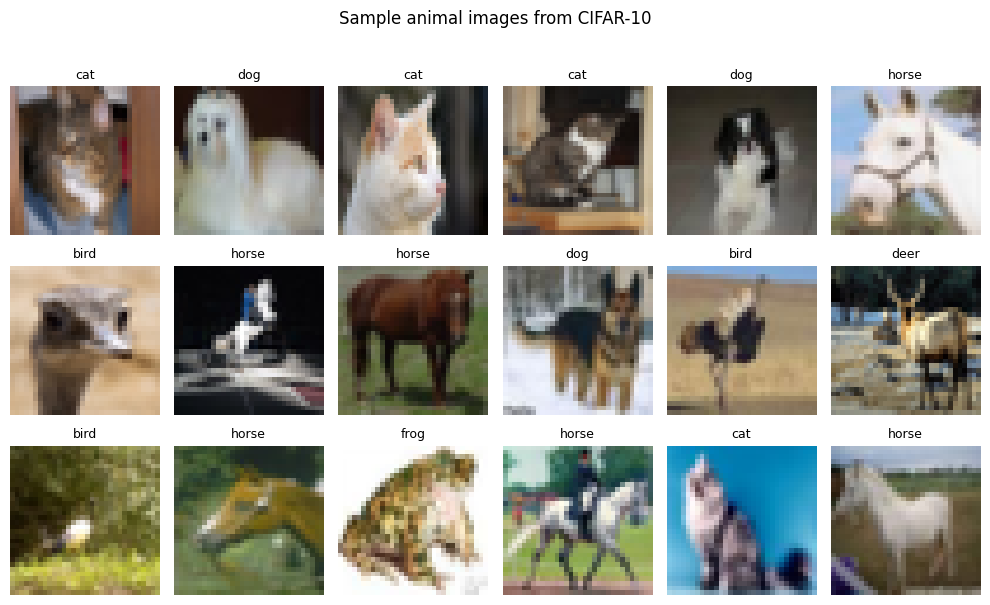

In [6]:
# --- 4a. Visualize a grid of sample images ---
plt.figure(figsize=(10, 6))
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(train_images), size=18, replace=False)

for plot_i, data_i in enumerate(sample_indices):
    plt.subplot(3, 6, plot_i + 1)
    plt.imshow(train_images[data_i])            # images are already uint8 RGB, 0-255
    plt.title(ANIMAL_NAMES[train_labels[data_i]], fontsize=9)
    plt.axis('off')

plt.suptitle("Sample animal images from CIFAR-10", y=1.02)
plt.tight_layout()
plt.show()


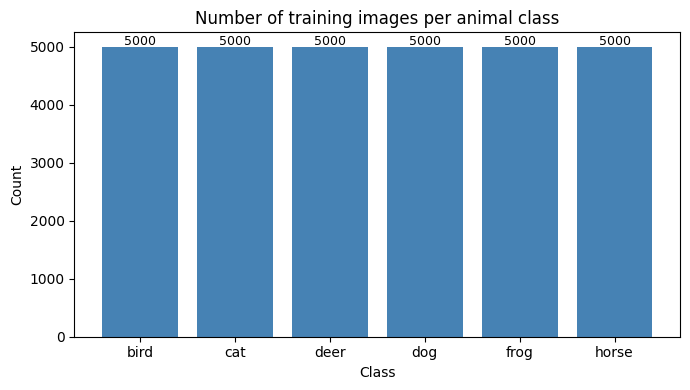

Training images per class: {'bird': np.int64(5000), 'cat': np.int64(5000), 'deer': np.int64(5000), 'dog': np.int64(5000), 'frog': np.int64(5000), 'horse': np.int64(5000)}


In [7]:
# --- 4b. Class balance check ---
unique, counts = np.unique(train_labels, return_counts=True)

plt.figure(figsize=(7, 4))
plt.bar([ANIMAL_NAMES[u] for u in unique], counts, color='steelblue')
plt.title("Number of training images per animal class")
plt.ylabel("Count")
plt.xlabel("Class")
for i, c in enumerate(counts):
    plt.text(i, c + 30, str(c), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Training images per class:", dict(zip([ANIMAL_NAMES[u] for u in unique], counts)))


## 5. Preprocess the Data

Three preprocessing steps happen here, each with a specific reason:

1. **Pixel normalization** — raw pixel values are integers from 0–255. Neural
   networks train much more reliably when their *inputs* are on a small,
   consistent scale (roughly 0–1 here). Large input values can make gradients
   explode or make some neurons saturate (e.g. a `sigmoid`/`relu` fed a value
   of 255 behaves very differently than one fed 1.0). We simply divide by
   `255.0`.

2. **Train / validation split** — we carve out a slice of the *training* data
   (not the test data!) to use as a **validation set**. The validation set is
   used *during training* to monitor whether the model is overfitting (i.e.
   memorizing the training data instead of learning general patterns), and to
   drive callbacks like early stopping. The **test set stays completely
   untouched** until the very end, so it gives us an honest, unbiased final
   accuracy number.

3. **One-hot encoding the labels** — our labels are currently plain integers
   (0–5). Because our model's output layer uses a `softmax` activation (which
   produces a probability for *each* of the 6 classes) paired with
   `categorical_crossentropy` loss, Keras expects the *true* label to be
   represented the same way: a vector of 6 numbers that's all zeros except a
   single `1` at the correct class's position, e.g. class `3` ("dog")
   becomes `[0, 0, 0, 1, 0, 0]`. This is called **one-hot encoding**.
   (Alternative: keep integer labels and use `sparse_categorical_crossentropy`
   — functionally equivalent, just a different bookkeeping convention. We use
   one-hot here because it keeps the confusion-matrix / metrics code below a
   little more explicit for beginners.)


In [9]:
# --- 5a. Normalize pixel values from [0, 255] to [0.0, 1.0] ---
train_images_norm = train_images.astype('float32') / 255.0
test_images_norm = test_images.astype('float32') / 255.0

# --- 5b. Carve a validation split out of the training data ---
# We shuffle first so the validation slice isn't accidentally all-one-class
# (the data currently sits in class-sorted blocks after filtering).
num_train = train_images_norm.shape[0]
shuffle_idx = rng.permutation(num_train)

train_images_norm = train_images_norm[shuffle_idx]
train_labels_shuffled = train_labels[shuffle_idx]

VALIDATION_FRACTION = 0.12          # 12% of training data reserved for validation
val_size = int(num_train * VALIDATION_FRACTION)

val_images = train_images_norm[:val_size]
val_labels = train_labels_shuffled[:val_size]

train_images_final = train_images_norm[val_size:]
train_labels_final = train_labels_shuffled[val_size:]

print(f"Training images:   {train_images_final.shape[0]}")
print(f"Validation images: {val_images.shape[0]}")
print(f"Test images:       {test_images_norm.shape[0]}")

# --- 5c. One-hot encode the integer labels ---
train_labels_oh = keras.utils.to_categorical(train_labels_final, NUM_CLASSES)
val_labels_oh = keras.utils.to_categorical(val_labels, NUM_CLASSES)
test_labels_oh = keras.utils.to_categorical(test_labels, NUM_CLASSES)

print("Example one-hot label:", train_labels_oh[0], "->", ANIMAL_NAMES[np.argmax(train_labels_oh[0])])


Training images:   26400
Validation images: 3600
Test images:       6000
Example one-hot label: [0. 0. 0. 0. 1. 0.] -> frog


## 6. Data Augmentation

With only ~27,000 training images spread across 6 classes, the CNN can start
**memorizing** specific training images rather than learning general visual
features — this is overfitting. **Data augmentation** fights this by applying
small, random, label-preserving transformations to each image *every time it's
shown to the model during training*, so the model effectively never sees the
exact same image twice.

We use Keras's built-in augmentation **layers**, which:
- Only run during training (`model.fit`) — at test/prediction time they pass
  images through unchanged.
- Run on the GPU alongside the rest of the model, which is fast.

Augmentations chosen, and why:
- `RandomFlip("horizontal")` — a horizontally-mirrored cat is still clearly a
  cat, so this is a free, safe way to double the effective variety of poses
  the model sees. (We do **not** flip vertically — an upside-down animal is a
  much less realistic training example and could hurt more than help.)
- `RandomRotation(0.06)` — small rotations (~±22°) simulate the fact that
  real photos aren't always perfectly level.
- `RandomZoom(0.1)` — small random zoom simulates the subject being slightly
  closer/farther from the camera.
- `RandomTranslation(0.1, 0.1)` — small shifts simulate the subject not being
  perfectly centered.

We deliberately keep these **mild**. CIFAR-10 images are only 32×32 pixels —
aggressive augmentation (e.g. large rotations or heavy zoom) can destroy the
little detail that exists and make even a human unable to recognize the
image, which would teach the model incorrect patterns.


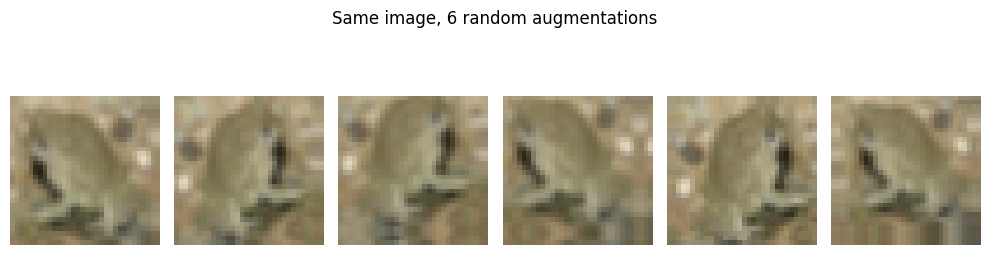

In [10]:
# A small sequential stack of augmentation layers. Each layer is a no-op
# during inference (model.predict / model.evaluate) and only randomizes
# during training (model.fit) -- Keras handles this automatically.
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.06),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")

# Quick visual sanity check: show the same image augmented several different ways.
plt.figure(figsize=(10, 3))
sample_image = train_images_final[0:1]   # keep a batch dimension: shape (1, 32, 32, 3)
for i in range(6):
    augmented = data_augmentation(sample_image, training=True)
    plt.subplot(1, 6, i + 1)
    plt.imshow(augmented[0])
    plt.axis('off')
plt.suptitle("Same image, 6 random augmentations")
plt.tight_layout()
plt.show()


## 7. Build the CNN Architecture

The network is a standard **"VGG-style"** stack: repeated blocks of
`[Conv -> BatchNorm -> Conv -> BatchNorm -> MaxPool -> Dropout]`, with the
number of filters doubling each block (32 → 64 → 128), followed by a small
dense "classifier head."

What each layer type is doing, in plain language:

- **`Conv2D`** — slides small filters (3×3 here) across the image to detect
  local visual patterns: edges and colors in early layers, textures and
  shapes (fur, feathers, wheels-vs-legs) in deeper layers. Using **two conv
  layers per block** before pooling (instead of one) lets the network build
  slightly more complex features before it throws away spatial resolution.
- **`BatchNormalization`** — rescales the outputs of a layer to have a
  stable mean/variance before they're passed on. This usually speeds up
  training and makes it more stable, letting us use a higher learning rate
  safely.
- **`MaxPooling2D(2,2)`** — shrinks the image dimensions by half, keeping only
  the strongest signal in each small region. This reduces computation and
  gives the network some tolerance to the exact position of a feature (a cat
  ear 2 pixels to the left is still "a cat ear").
- **`Dropout`** — randomly "turns off" a fraction of neurons during each
  training step, forcing the rest of the network to not over-rely on any
  single neuron/feature. This is one of the most important anti-overfitting
  tools in this notebook — notice the dropout rate **increases** as we go
  deeper (0.25 → 0.25 → 0.25 → 0.5), since the final, most "memorization-prone"
  dense layer needs the strongest regularization.
- **`Flatten`** — converts the final 3D feature maps into a single 1D vector
  so they can be fed into regular (`Dense`) layers.
- **`Dense(256, activation='relu')`** — a fully-connected layer that combines
  all the extracted visual features to start forming a decision.
- **Final `Dense(NUM_CLASSES, activation='softmax')`** — outputs a probability
  distribution over our 6 animal classes (all 6 numbers are between 0 and 1
  and sum to 1).

The data-augmentation block from Section 6 is placed as the **first layer**
of the model itself (rather than being applied separately beforehand). This
has a convenient side effect: it keeps augmentation logic bundled with the
model, and it's automatically skipped whenever the model is used in
inference mode (`training=False`), which is exactly the behavior we want.


In [11]:
def build_model(input_shape=(32, 32, 3), num_classes=NUM_CLASSES):
    '''Builds and returns a compiled-ready (but not yet compiled) CNN.'''

    inputs = keras.Input(shape=input_shape)

    # Augmentation happens first, and only has an effect when training=True.
    x = data_augmentation(inputs)

    # --- Block 1: 32 filters ---
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # --- Block 2: 64 filters ---
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # --- Block 3: 128 filters ---
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # --- Classifier head ---
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name="animal_cnn")


model = build_model()
model.summary()


Model: "animal_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,54

 Total params: 815,910 (3.11 MB)

 Trainable params: 814,502 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 8. Compile the Model

Compiling attaches three things to the model:

- **Optimizer — `Adam`**: an adaptive-learning-rate optimizer that's a strong,
  low-maintenance default for most image classification tasks. We start with
  a learning rate of `0.001` (Keras's Adam default), which is a reasonable
  starting point — see the hyperparameter discussion at the end of this
  notebook for how to tune it.
- **Loss — `categorical_crossentropy`**: the standard loss function for
  multi-class classification when labels are one-hot encoded. It penalizes
  the model proportionally to how far its predicted probability for the
  *correct* class was from 1.0.
- **Metric — `accuracy`**: simply the fraction of images classified
  correctly. We track this (rather than only loss) because it's the most
  intuitive, human-readable measure of performance.


In [12]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


## 9. Callbacks

Callbacks are functions that run automatically at certain points during
training (e.g. "end of every epoch"). We use three:

- **`EarlyStopping`** — watches `val_loss` (validation loss). If it hasn't
  improved for `patience` epochs in a row, training stops automatically and
  the best-performing weights are restored
  (`restore_best_weights=True`). This is our main defense against training
  for "too long" and overfitting: left alone, training accuracy will keep
  climbing even after the model has stopped generalizing better, and
  `val_loss` starting to creep back up is the tell-tale sign.
- **`ReduceLROnPlateau`** — if `val_loss` stalls for a few epochs (fewer than
  `EarlyStopping`'s patience), this cuts the learning rate by a factor
  (`factor=0.5`) rather than giving up entirely. A smaller learning rate lets
  the optimizer take smaller, more careful steps, which often squeezes out a
  bit more accuracy once progress has plateaued at a larger step size.
- **`ModelCheckpoint`** — saves the single best version of the model (by
  `val_accuracy`) to disk as training progresses, so we always have the best
  version available even if something goes wrong later in training.


In [13]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,                 # stop if no improvement for 10 epochs
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,                  # halve the learning rate...
        patience=4,                  # ...if val_loss stalls for 4 epochs
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_animal_cnn.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
]


## 10. Train the Model

A few notes on the settings below:

- **`epochs=60`** — an upper bound on how long we're *willing* to train.
  Because `EarlyStopping` is active, training will very likely stop well
  before reaching 60 epochs once validation performance plateaus — this
  number mainly just needs to be "comfortably larger than you expect to
  need."
- **`batch_size=64`** — the number of images the model looks at before each
  weight update. It's a classic hyperparameter trade-off: smaller batches
  update more often (potentially better accuracy, slower wall-clock time per
  epoch), larger batches are faster per-epoch but each update is "smoother"
  and can sometimes generalize slightly worse. 64 is a solid default for a
  dataset and image size like this one.

Expect each epoch to take anywhere from a few seconds (GPU) to a minute or
more (CPU only).


In [14]:
EPOCHS = 10
BATCH_SIZE = 64

history = model.fit(
    train_images_final, train_labels_oh,
    validation_data=(val_images, val_labels_oh),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.3176 - loss: 2.0302
Epoch 1: val_accuracy improved from None to 0.30028, saving model to best_animal_cnn.keras

Epoch 1: finished saving model to best_animal_cnn.keras
413/413 ━━━━━━━━━━━━━━━━━━━━ 231s 543ms/step - accuracy: 0.3638 - loss: 1.7734 - val_accuracy: 0.3003 - val_loss: 2.0908 - learning_rate: 0.0010
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.4576 - loss: 1.4198
Epoch 2: val_accuracy improved from 0.30028 to 0.46833, saving model to best_animal_cnn.keras

Epoch 2: finished saving model to best_animal_cnn.keras
413/413 ━━━━━━━━━━━━━━━━━━━━ 261s 541ms/step - accuracy: 0.4766 - loss: 1.3698 - val_accuracy: 0.4683 - val_loss: 1.4950 - learning_rate: 0.0010
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.5159 - loss: 1.2509
Epoch 3: val_accuracy improved from 0.46833 to 0.52333, saving model to best_animal_cnn.keras

Epoch 3: finished saving model to best_animal_cnn.ke

## 11. Visualize Training History

Plotting accuracy and loss for both the training and validation sets, epoch
by epoch, is the single best diagnostic tool for spotting overfitting:

- If **training accuracy** keeps rising while **validation accuracy**
  flattens or falls, the model is starting to memorize the training set
  rather than learn generalizable patterns — classic overfitting.
- If **both** curves are low and close together, the model is likely
  **underfitting** (too simple, or stopped too early, or too much
  regularization/dropout).
- The "sweet spot" is where both curves rise together and the gap between
  them stays small.


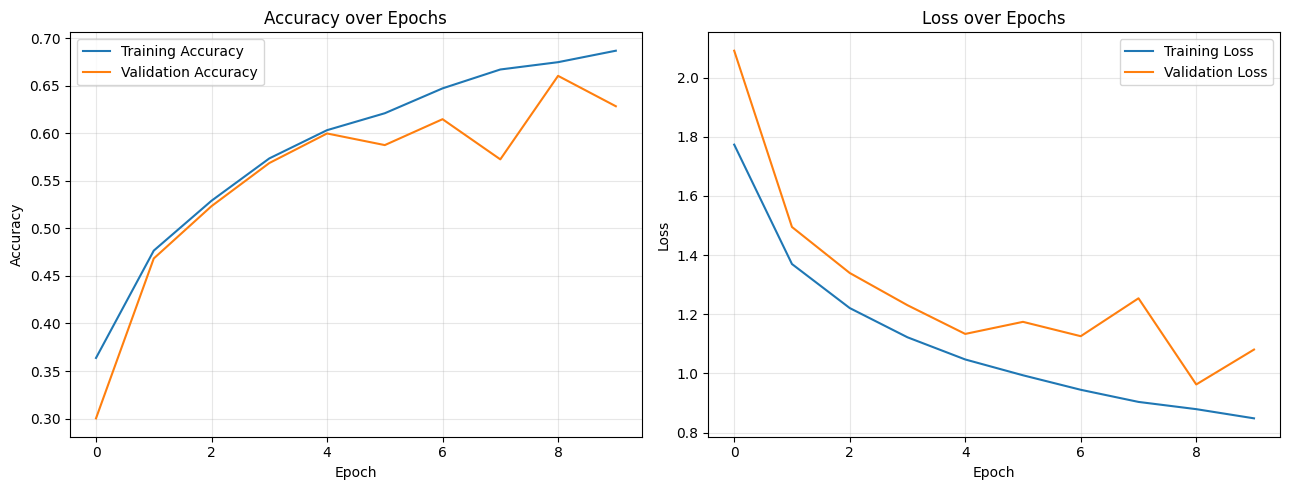

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Accuracy curves ---
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Loss curves ---
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 12. Evaluate on the Held-Out Test Set

This is the **first and only time** we touch `test_images_norm` /
`test_labels_oh`. Because the model never saw these images (directly or via
hyperparameter tuning decisions), this number is our most honest estimate of
how the model would perform on brand-new animal photos.


In [16]:
test_loss, test_accuracy = model.evaluate(test_images_norm, test_labels_oh, verbose=0)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}  ({test_accuracy * 100:.2f}%)")


Test loss:     0.9437
Test accuracy: 0.6708  (67.08%)


## 13. Per-Class Performance: Confusion Matrix & Classification Report

Overall accuracy hides a lot of detail. A **confusion matrix** shows, for
every true class, exactly which classes the model confused it with. For
this specific dataset, don't be surprised to see notable confusion between
visually/texturally similar pairs like `cat` vs `dog`, or `deer` vs `horse`.

`classification_report` additionally breaks down **precision**, **recall**,
and **F1-score** per class:
- **Precision**: of all the times the model predicted "cat", how often was
  it actually a cat?
- **Recall**: of all the actual cat images, how many did the model correctly
  catch?
- **F1-score**: the harmonic mean of precision and recall, a single balanced
  number per class.


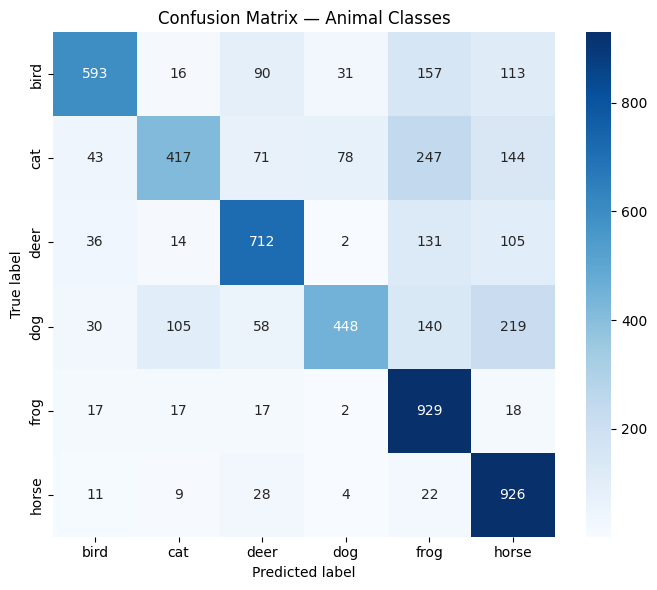

              precision    recall  f1-score   support

        bird       0.81      0.59      0.69      1000
         cat       0.72      0.42      0.53      1000
        deer       0.73      0.71      0.72      1000
         dog       0.79      0.45      0.57      1000
        frog       0.57      0.93      0.71      1000
       horse       0.61      0.93      0.73      1000

    accuracy                           0.67      6000
   macro avg       0.71      0.67      0.66      6000
weighted avg       0.71      0.67      0.66      6000



In [17]:
# Get the model's predicted probabilities for every test image, then take
# the class with the highest probability as the final prediction.
predictions_prob = model.predict(test_images_norm, verbose=0)
predicted_labels = np.argmax(predictions_prob, axis=1)
true_labels = np.argmax(test_labels_oh, axis=1)

# --- Confusion matrix ---
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ANIMAL_NAMES, yticklabels=ANIMAL_NAMES)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix — Animal Classes')
plt.tight_layout()
plt.show()

# --- Precision / recall / F1 per class ---
print(classification_report(true_labels, predicted_labels, target_names=ANIMAL_NAMES))


## 14. Inspect Individual Predictions

Numbers are useful, but looking at actual mistakes often reveals *why* the
model struggles with certain classes (e.g. blurry images, unusual poses, or
an animal that's genuinely ambiguous even to a human at 32×32 resolution).


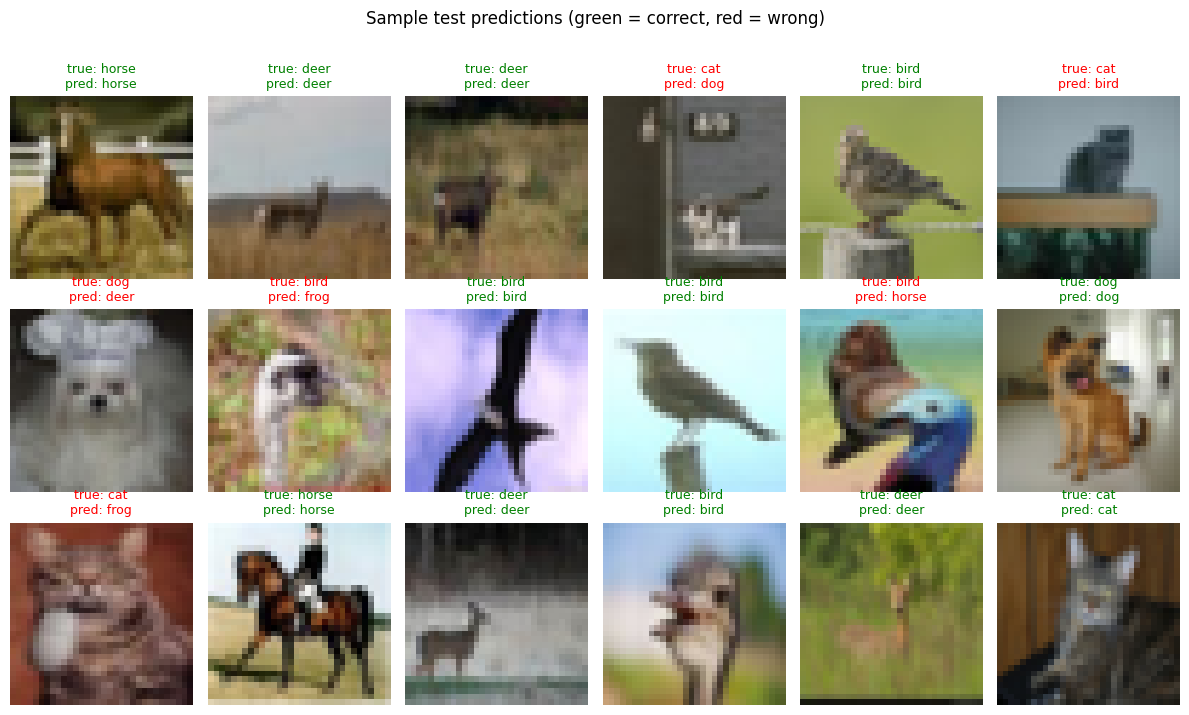

In [18]:
plt.figure(figsize=(12, 7))
sample_test_idx = rng.choice(len(test_images_norm), size=18, replace=False)

for plot_i, data_i in enumerate(sample_test_idx):
    plt.subplot(3, 6, plot_i + 1)
    plt.imshow(test_images_norm[data_i])

    true_name = ANIMAL_NAMES[true_labels[data_i]]
    pred_name = ANIMAL_NAMES[predicted_labels[data_i]]
    is_correct = true_labels[data_i] == predicted_labels[data_i]

    color = 'green' if is_correct else 'red'
    plt.title(f"true: {true_name}\npred: {pred_name}", color=color, fontsize=9)
    plt.axis('off')

plt.suptitle("Sample test predictions (green = correct, red = wrong)", y=1.02)
plt.tight_layout()
plt.show()


## 15. Save the Trained Model

Saving the full model (architecture + trained weights + optimizer state)
lets us reload it later for inference without retraining from scratch.


In [19]:
model.save('animal_cnn_final.keras')
print("Model saved to animal_cnn_final.keras")


Model saved to animal_cnn_final.keras


## 16. Hyperparameters Worth Tuning (and the Overfitting Trade-off)

Getting better accuracy is usually easy in isolation — the hard part is
getting better accuracy **without** the model just memorizing the training
set. Below is a practical, prioritized list.

### Likely to help accuracy *and* keep overfitting in check
| Hyperparameter | Where | What to try | Why |
|---|---|---|---|
| **Learning rate** | `Adam(learning_rate=...)` | Try `3e-4` or `5e-4` instead of `1e-3`; combine with more epochs | A smaller learning rate can reach a better minimum, especially once `ReduceLROnPlateau` is already in play. Too small, and training becomes painfully slow/underfits in the epoch budget you allow. |
| **EarlyStopping `patience`** | callbacks | Try 5–15 | Lower patience = safer against overfitting but risks stopping before the model has fully converged; higher patience = more training time to improve, but more risk of overfitting if validation loss is noisy rather than truly plateaued. |
| **Dropout rates** | each `Dropout(...)` | Try 0.2–0.5 range, tune block-by-block | More dropout = more regularization (less overfitting) but can underfit if pushed too high, especially in early conv blocks where you don't want to destroy too much signal before features even form. |
| **Data augmentation strength** | `RandomRotation`, `RandomZoom`, etc. | Try increasing rotation to `0.1`, zoom to `0.15` | More aggressive augmentation = effectively a larger, more varied training set = less overfitting. Push too far on 32×32 images, though, and you create unrealistic/unrecognizable training examples, which *hurts* accuracy. |
| **L2 weight regularization** | add `kernel_regularizer=keras.regularizers.l2(1e-4)` to `Conv2D`/`Dense` layers | `1e-5` to `1e-3` | Penalizes large weights directly, which is a complementary regularizer to dropout. |

### Likely to help raw accuracy, but can increase overfitting risk if not paired with the regularization above
| Hyperparameter | Where | What to try | Why |
|---|---|---|---|
| **Model depth / width** | `build_model()` | Add a 4th conv block (256 filters), or more filters per block | More capacity can fit more complex patterns — but also makes memorizing the training set easier, so increase dropout/augmentation alongside this. |
| **Dense layer size** | `Dense(256, ...)` | Try 128–512 | A bigger dense layer can learn richer combinations of features, but is also the most overfitting-prone part of the network (it's the part closest to "memorizing" specific training examples). |
| **Number of epochs allowed** | `EPOCHS` | Raise the ceiling (e.g. 100) | Only helps if `EarlyStopping`/`ReduceLROnPlateau` are correctly configured to actually stop/adjust at the right time — otherwise this just gives the model more time to overfit. |

### Mostly about training efficiency/stability (indirect effect on accuracy)
| Hyperparameter | Where | What to try | Why |
|---|---|---|---|
| **Batch size** | `BATCH_SIZE` | Try 32 or 128 | Smaller batches: noisier but sometimes better-generalizing updates, slower per epoch. Larger batches: smoother, faster per epoch, sometimes needs a slightly higher learning rate to compensate. |
| **Validation split size** | `VALIDATION_FRACTION` | Try 0.10–0.20 | More validation data gives a more reliable overfitting signal for EarlyStopping, at the cost of slightly less training data. |

### How to tune responsibly (avoid "cheating" on the test set)
1. **Only ever use the validation set** (not the test set) while trying
   different hyperparameter values. The test set should be evaluated **once**,
   at the very end, after you've already settled on your final configuration.
2. Change **one hyperparameter at a time** where possible, so you can tell
   what actually caused a change in behavior.
3. Always look at the **train vs. validation curves** (Section 11) together
   with the accuracy number — a model with 95% train accuracy but 70%
   validation accuracy is in worse shape than one with 85%/82%, even though
   the first has higher *training* accuracy.
4. If validation accuracy plateaus or drops while training accuracy keeps
   rising, that's your signal to **increase regularization** (dropout, L2,
   stronger augmentation) or **reduce model capacity**, not to train longer.
